## GenImage Metadata EDA
We implement the downloaded metadata dataset in `data\raw\genimage_meta` to decide how to build the actual image dataset prior to actually downloading any images. 

#### Goal
The main question this notebook seeks to answer is **Whether a model can classify the metadata alone without looking at a single pixel**. If the answer is yes, then a shortcut signal exists which we aim to close.

#### Deliverable
This notebook produces two things:
  - A completed `configs/data/subset_v1.yaml` which entails recordings of bias matching configurations, train-val-test splits, in-distribution and out of distribution generators, and other statistics...
  - Generated plots to support EDA evidence in `reports/data_card.md`

---

### 0. Setup
Assuming the virtual environment is created and dependencies installed using the `Pyproject.toml`, to allow the notebook to detect the Python kernel from the project `venv` first register the `venv` as a Jupyter kernel as follows: 
```bash
python -m ipykernel install --user --name ai-detector --display-name "Python (ai-detector)"
```


In [1]:
## In case of module updates
%load_ext autoreload
%autoreload 2

## Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ai_detector.data.selection import(SubsetConfig, normalize_columns, apply_matching, shortcut_probe)
from ai_detector.data import viz


## File Paths
PROJECT_ROOT= Path.cwd().parent
DATA= PROJECT_ROOT / "data"
META_CSV= DATA 
DATA = PROJECT_ROOT / "data"
META_CSV = DATA / "raw" / "genimage_meta" / "genimage_metadata.csv"
FIGDIR = PROJECT_ROOT / "reports" / "figures"

## Display options
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("metadata present:", META_CSV.exists())

metadata present: True


If printed  `False`, run the downloader from the project root if not yet done
```bash
python scripts/download_genimage_metadata.py --dest data/raw/genimage_meta
```

Otherwise, confirm the file name provided in `META_CSV` path variable matches with the actual file name in `data/raw/genimage_meta`

---

### 1. Schema Audit
Understanding the metadata dataset


In [2]:
raw= pd.read_csv(META_CSV, encoding= "utf-8")
print(f"{raw.shape[0]} rows, {raw.shape[1]} columns")
print()
raw.info()
print()
display(raw.head(5))

2681150 rows, 7 columns

<class 'pandas.DataFrame'>
RangeIndex: 2681150 entries, 0 to 2681149
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   path              str  
 1   generator         str  
 2   mode              str  
 3   width             int64
 4   height            int64
 5   compression_rate  int64
 6   class             int64
dtypes: int64(4), str(3)
memory usage: 309.3 MB



,path,generator,mode,width,height,compression_rate,class
0,GenImage/Midjourney/train/ai/176_midjourney_52...,Midjourney,train,1024,1024,100,176
1,GenImage/Midjourney/train/ai/44_midjourney_19.png,Midjourney,train,1024,1024,100,44
2,GenImage/Midjourney/train/ai/310_midjourney_19...,Midjourney,train,1024,1024,100,310
3,GenImage/Midjourney/train/ai/558_midjourney_4.png,Midjourney,train,1024,1024,100,558
4,GenImage/Midjourney/train/ai/546_midjourney_40...,Midjourney,train,1024,1024,100,546


In [3]:
## Cardinality and nulls at a glance. `nunique` on a 1M-row frame is cheap and tells you instantly which columns are identifiers, which are categories, and which are continuous.
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_null": raw.isna().sum(),
    "pct_null": (raw.isna().mean() * 100).round(2),
    "example": [raw[c].dropna().iloc[0] if raw[c].notna().any() else None for c in raw.columns],
})
display(summary)

,dtype,n_unique,n_null,pct_null,example
path,str,2681150,0,0.0,GenImage/Midjourney/train/ai/176_midjourney_52...
generator,str,9,0,0.0,Midjourney
mode,str,2,0,0.0,train
width,int64,2720,0,0.0,1024
height,int64,2498,0,0.0,1024
compression_rate,int64,98,0,0.0,100
class,int64,1000,0,0.0,176


Column descriptions:
| **Column Name** | **Description** | 
| ----------| -------------| 
| `path` | Where the actual image is stored | 
| `generator` | The AI generator that produced the image. Real images are otherwise labelled `nature`|
| `mode` | training and validation set |
| `width` | Width of the image | 
| `Height` | Height of the image |
| `compression_rate` | JPEG Quality Factor (QF) of the image ranging from 0-100 | 
| `class` | Correspond to the ImageNet-1K category index (0-999) to control content distribution when pairing real and generated images (e.g.- Images of an ant (`152`), lizard (`44`), electric guitar (`546`) and so on). This ensures the model purely evaluates AI detection rather than object differences.|

In [4]:
## Normalize column names
df = normalize_columns(raw)
print("columns after normalisation:", list(df.columns))

missing = {"generator", "width", "height"} - set(df.columns)
assert not missing, f"missing critical columns: {missing} -- add a manual mapping"
  # In case critical column names {"generator", "width", "height"} are missing

columns after normalisation: ['path', 'generator', 'mode', 'width', 'height', 'jpeg_qf', 'content_class']


In [5]:
## Assessinng elements per column feature
for c in ["mode", "generator", "jpeg_qf", "content_class"]:
    print(df[c].value_counts())
    print("--"* 15)

mode
train    2581150
val       100000
Name: count, dtype: int64
------------------------------
generator
nature                    1331167
stable_diffusion_v_1_5     174000
VQDM                       168000
wukong                     168000
glide                      167999
Midjourney                 167997
stable_diffusion_v_1_4     167997
BigGAN                     167996
ADM                        167994
Name: count, dtype: int64
------------------------------
jpeg_qf
100    1361807
96      903382
75       67096
80       56349
90       36479
        ...   
0            2
3            2
4            1
1            1
5            1
Name: count, Length: 98, dtype: int64
------------------------------
content_class
176    2700
44     2700
310    2700
558    2700
546    2700
       ... 
152    2172
268    2155
167    2154
175    2138
165    2132
Name: count, Length: 1000, dtype: int64
------------------------------


----

### 2. Shape of the World
We count the following from the metadata dataset:
  1. **Rows per generator**- Tells us the fake side balance
  2. **Real:Fake Ratio** which tells us whether:
     - Real images are ~50% of the whole table (a single-shared pool) or...
     - Real images equal fake images *per generator*.
  
  3. **Real image duplicates**- Real images will be split across the training set, in-generator-distribution test set and out-of-distribution test set (`test_ood_genimage`). If real image identities repeat, there is a risk the same image can land in more than one of each set which means our model evaluation results would be partly a memorisation score. 

In [6]:
## Rows per generator
gen_counts = df["generator"].value_counts()
display(gen_counts.to_frame("n_images"))

## Check if real images actually exist in the data
REAL_TOKEN = "nature"   # verify this against the value_counts above!
assert REAL_TOKEN in gen_counts.index, f"'{REAL_TOKEN}' not found -- what token marks real images?"

## Class balance check
df["label"] = (df["generator"] != REAL_TOKEN).astype(int)
print("\nclass balance:")
print(df["label"].value_counts(normalize=True).rename({0: "human", 1: "AI"}).round(3))

,n_images
generator,
nature,1331167
stable_diffusion_v_1_5,174000
VQDM,168000
wukong,168000
glide,167999
Midjourney,167997
stable_diffusion_v_1_4,167997
BigGAN,167996
ADM,167994



class balance:
label
AI       0.504
human    0.496
Name: proportion, dtype: float64


No class imbalance in the data as per above check

In [7]:
## Are real images duplicated across image generator subsets?
id_col = "path" if "path" in df.columns else df.columns[0]
  # We need a stable identity for a real image. The file basename is usually it (ImageNet filenames are unique). 
  # If your metadata has no path column, use whatever identifier exists.
reals = df[df["label"] == 0].copy()
reals["basename"] = reals[id_col].astype(str).str.rsplit("/", n=1).str[-1]

dupes = reals["basename"].duplicated().sum()
print(f"real rows: {len(reals):,}")
print(f"real rows whose basename repeats elsewhere: {dupes:,}")
print(f"distinct real basenames: {reals['basename'].nunique():,}")

if dupes:
    print("\n>>> Reals ARE shared across generator subsets.")
    print(">>> Consequence: you cannot split by generator alone. Real GROUPS")
    print(">>> must be partitioned explicitly between the in-dist pool and the")
    print(">>> OOD pool (this is what assign_genimage_splits does).")
else:
    print("\n>>> Each real image appears once. Splitting by generator is safe on the real side.")

real rows: 1,331,167
real rows whose basename repeats elsewhere: 0
distinct real basenames: 1,331,167

>>> Each real image appears once. Splitting by generator is safe on the real side.


---

### 3. Classification Without Pixels
This is the whole argument of this notebook where we seek to discover whether there is any shortcut signal present by performing classification based on image metadata alone. 

We fit a very simple depth-3 decision-tree on only `width`, `height` and `jpeg_qf` and score it via 5-fold cross-validation.

Cross-validation is preferred rather than a single split first due to the large dataset size that can allow for C-V in the first place, and also, a single split of a large table may be unstable and C-V allows us to assess the variance across folds and provide us with a mean score.

The closer the score is to 0.5, the better as it means there is not discernable signal from the metadata.

In [8]:
## We define the initial accuracy score before any dataset transformation or bias matching
folds= [2, 5, 10, 20, 70]
print("Metadata-Only Accuracy Per Fold")
print("--"* 20)
for f in folds: 
    acc_before= shortcut_probe(df, n_folds= f)
    print(f"n_folds: {f}: {round(acc_before, 3)}")

Metadata-Only Accuracy Per Fold
----------------------------------------
n_folds: 2: 0.872
n_folds: 5: 0.934
n_folds: 10: 0.996
n_folds: 20: 0.996
n_folds: 70: 0.996


This tells us the shortcut is in fact a very dominant signal in the dataset. Though which feature is most likely producing it?

In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text

feat = [c for c in ("width", "height", "jpeg_qf") if c in df.columns]
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(
    df[feat].fillna(-1), df["label"])

print(export_text(tree, feature_names=feat, max_depth=3)) 
  # Expose the classification rules of the decision tree
print("\nfeature importances:", dict(zip(feat, tree.feature_importances_.round(3))))

|--- jpeg_qf <= 99.50
|   |--- class: 0
|--- jpeg_qf >  99.50
|   |--- height <= 127.50
|   |   |--- class: 0
|   |--- height >  127.50
|   |   |--- width <= 1024.50
|   |   |   |--- class: 1
|   |   |--- width >  1024.50
|   |   |   |--- class: 0


feature importances: {'width': np.float64(0.001), 'height': np.float64(0.001), 'jpeg_qf': np.float64(0.998)}


From the above feature importances, an incredible **99.8%** of predictive signal lies within JPEG QF. Very minimal signal lies is the image dimensions.

---

In [10]:
display(df[df["generator"]== "nature"].head())

,path,generator,mode,width,height,jpeg_qf,content_class,label
161997,GenImage/Midjourney/train/nature/n02807133_231...,nature,train,500,333,96,433,0
161998,GenImage/Midjourney/train/nature/n02177972_178...,nature,train,500,399,96,307,0
161999,GenImage/Midjourney/train/nature/n04263257_440...,nature,train,500,333,96,809,0
162000,GenImage/Midjourney/train/nature/n01983481_138...,nature,train,518,691,75,122,0
162001,GenImage/Midjourney/train/nature/n04243546_283...,nature,train,500,375,96,800,0


### 4. Shortcut Signal: JPEG QF
The above finding corresponds to the findings of [Grommet et al. (2024)](https://arxiv.org/abs/2403.17608). AI generators emit images at consistent JPEG QF compared to real images which, as found in their study, are uncompressed PNGs, or can be JPEGs with various encoder values.

In [11]:
## Snapshot of QF values for sampled images (real vs. fake)
# Real
print("Real Images")
display(df[df["generator"]== "nature"].sample(5))
print()
print("AI Generated Images")
display(df[df["generator"]!= "nature"].sample(5))

Real Images


,path,generator,mode,width,height,jpeg_qf,content_class,label
2340993,GenImage/glide/val/nature/ILSVRC2012_val_00026...,nature,val,500,375,96,118,0
388045,GenImage/stable_diffusion_v_1_4/train/nature/n...,nature,train,336,448,96,505,0
890640,GenImage/ADM/train/nature/n04372370_58.JPEG,nature,train,250,320,94,844,0
2639176,GenImage/stable_diffusion_v_1_5/train/nature/n...,nature,train,500,375,96,825,0
1129866,GenImage/BigGAN/train/nature/n03729826_25629.JPEG,nature,train,302,470,93,644,0



AI Generated Images


,path,generator,mode,width,height,jpeg_qf,content_class,label
28944,GenImage/Midjourney/train/ai/328_midjourney_46...,Midjourney,train,1024,1024,100,328,1
1218502,GenImage/BigGAN/train/ai/262_biggan_00189.png,BigGAN,train,128,128,100,262,1
1704861,GenImage/wukong/train/ai/717_wukong_image12.png,wukong,train,512,512,100,717,1
1738558,GenImage/wukong/train/ai/307_wukong_image181.png,wukong,train,512,512,100,307,1
2243195,GenImage/glide/train/ai/GLIDE_1000_200_01_147_...,glide,train,256,256,100,147,1


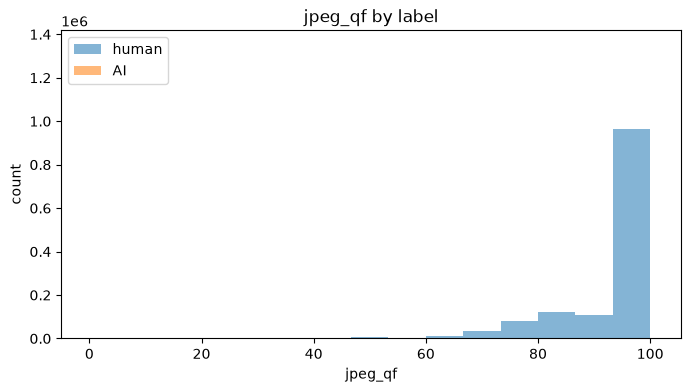

,label,jpeg_qf,share
0,0,96,0.678639
1,0,75,0.050404
2,0,80,0.042331
3,0,90,0.027404
4,0,92,0.025313
5,0,85,0.023700
6,1,100,1.000000



QF concentration (share of class in its single most common QF):
label
0    0.679
1    1.000
Name: jpeg_qf, dtype: float64


In [12]:
## JPEG Analysis
if "jpeg_qf" in df.columns: # Ensure jpeq_qf is part of the dataset
    fig = viz.dist_by_label(df, "jpeg_qf", bins=15)
    viz.save(fig, "01_jpeg_qf_by_label", FIGDIR)
    plt.show()

    qf_top = (df.groupby("label")["jpeg_qf"]
                .value_counts(normalize=True)
                .groupby(level=0).head(6)
                .rename("share").reset_index())
    display(qf_top)

    print("\nQF concentration (share of class in its single most common QF):")
    print(df.groupby("label")["jpeg_qf"].apply(lambda s: s.value_counts(normalize=True).max()).round(3))
else:
    print("No jpeg_qf column -- you will have to recover it from the files themselves....")
    print("...in notebook 02 using integrity.estimate_jpeg_quality().")

From the plotted figure, there is a clear JEPG QF distinction between real and AI generated images. We also find **all** AI generated images have a JPWG QF value if 100 compared to real images with varied JPEG QF values.

---

### 5. Shortcut Signal: Dimensions
Even if image dimensions (height, width) provide far less predictive signal, they should still be investigated.

We plot a scatter plot of width vs height colored by generator to determine whether such dimensions are separable by generator. 

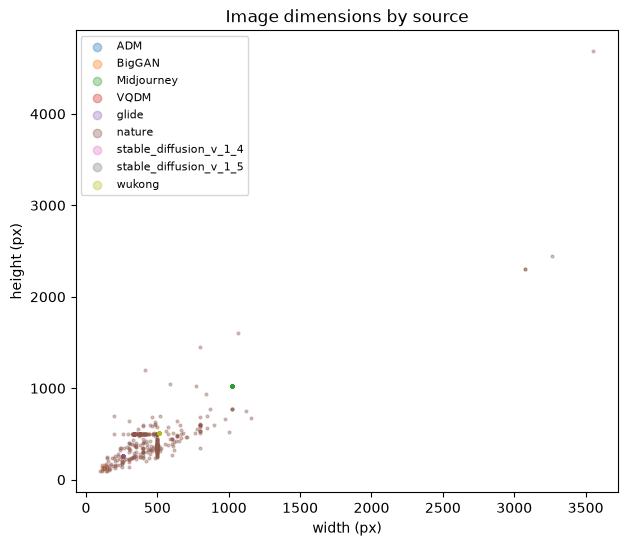

In [13]:
sample = df.sample(min(len(df), 120_000), random_state=0)
fig = viz.size_scatter(sample, hue="generator", max_points= 700)
viz.save(fig, "01_size_scatter_by_generator", FIGDIR)
plt.show()

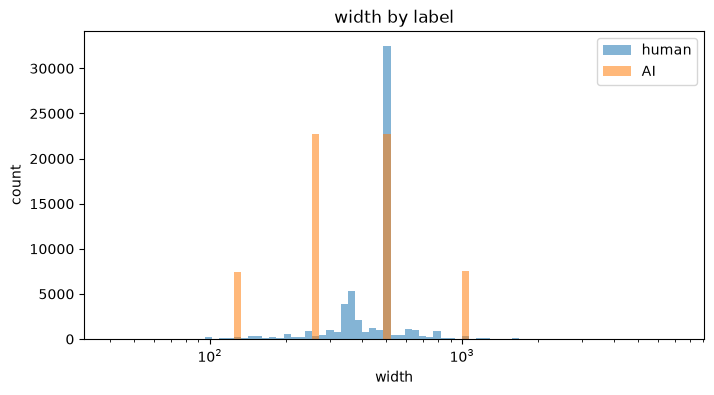

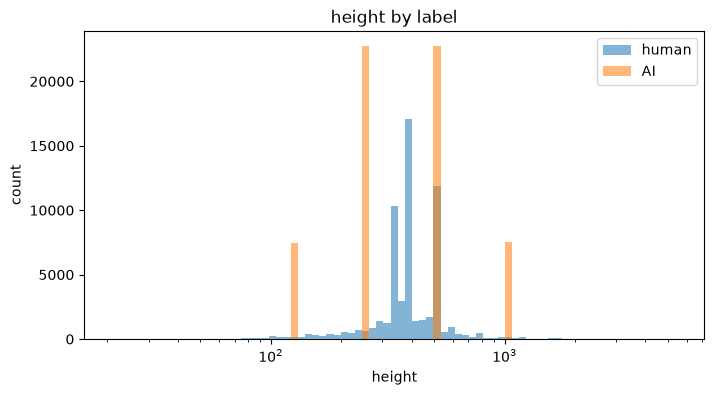

is_512,False,True
label,,
0,1314639,16528
1,839804,510179


In [41]:
for col, log in [("width", False), ("height", False)]:
    fig = viz.dist_by_label(sample, col, bins=80, density= False, log= True)
    viz.save(fig, f"01_{col}_by_class", FIGDIR)
    plt.show()

# Quantify the overlap rather than eyeballing it.
size_tab = (
    df.assign(is_512=(df["width"].between(500, 520) & df["height"].between(500, 520)))
      .groupby(["label", "is_512"], observed=True).size().unstack(fill_value=0)
)
display(size_tab)

### 6. Content Balance
We check whether content (i.e.- dog, spider, mushroom, car, etc...) is balanced across real and AI-generated images. If certain content classes are over-represented in either label, then the model risks learning from the semantic shortcut. 

We measure content balance using **total variation distance (TVD)** between real and fake content-class distributions. TVD is a statistical measure that tells you how different two probability distributions (i.e.- $P$ and $Q$) are different from each other.

$$\text{TVD}(P, Q) = \max_{A} |P(A) - Q(A)|$$

In our image analysis context we want to check how identical/how different class mixes are between real and AI generated images.

$$\text{TVD}(p_{real}, p_{fake}) = 0.5 \times \sum_{x} \vert p_{real}(x) - p_{fake}(x)$$

Where:
  - $x$ is a specific image
  - $p_{real}(x)$ is the probability of seeing a real image in the dataset
  - $p_{fake}(x)$ is the probability of the generator producing that exact image
  - $0.5$ normalizes the distance between 0 and 1

TVD ranges from 0 to 1 where:
  - TVD = 0: Identical class mixes (The ideal score)
  - TVD = 1: Completely different class mixes

We would want identical class mixes to prevent content alone from being informative about the label. A score of below 0.3 is recommended.


In [15]:
if "content_class" in df.columns:
    p_real= df[df.label == 0]["content_class"].value_counts(normalize= True)
    p_fake= df[df.label == 1]["content_class"].value_counts(normalize= True)
    aligned= pd.concat([p_real, p_fake], axis= 1, keys= ["real", "fake"]).fillna(0)
    tv = 0.5 * (aligned["real"] - aligned["fake"]).abs().sum()
    print(f"content classes: {len(aligned)}   TV distance real vs fake: {tv:.4f}")
    display(aligned.assign(diff=(aligned.real - aligned.fake).abs())
                   .sort_values("diff", ascending=False).head(10))
else:
    print("No content_class column found.")

content classes: 1000   TV distance real vs fake: 0.0127


,real,fake,diff
content_class,,,
165,0.000587,0.001,0.000413
175,0.000592,0.001,0.000408
167,0.000604,0.001,0.000396
268,0.000605,0.001,0.000395
152,0.000618,0.001,0.000383
158,0.000684,0.001,0.000316
531,0.000705,0.001,0.000295
596,0.000707,0.001,0.000293
740,0.000720,0.001,0.000280


### 7. Selecting the held-out generators
We select the generators that will be out-of-distribution (`test_ood_genimage`) (i.e.- Will only be utilized during model testing). We can employ two criteria:

#### Architecture Family
The following image generators currently under consideration (`Midjourney`, `nature`, `stable_diffusion_v_1_4`, `ADM`, `BigGAN`, `VQDM`, `wukong`, `glide`, `stable_diffusion_v_1_5`) span three generation families:
  - **Generative Adversarial Network (GAN)** -> It takes in random input noise and tries to make it as real as possible while a *discriminator* neural network within its architecture evaluates the GANs output against the actual (real) dataset. GAN therefore prevails once it "fools" the discriminator (i.e.- The discriminator cannot tell between the real data and the GANs fake output) (`BigGAN`).
  - **Diffusion models** -> It first starts with a clear, real photo, then adds noise to it over thousands of steps until the image is indistinguishable from random static. A *UNet* neural network within its architecture then reverses the process, removing the embedded noise until a finished image remains (`ADM`, `GLIDE`, `Stable Diffusion`, `Wukong`, `Midjourney`).
  - **VQ (Vector Quantization) / latent-discrete diffusion** -> It first encodes the raw image into continuous vectors, which are then mapped to its already learned vector representations known as a *codebook*. It then learns the relationship between each code then draws from it to turn initial random noise into a generated image (latent diffusion) (`VQDM`).

Therefore, when holding out a particular model we must ensure the held out set is from a different family than the in-distribution generator set to ensure we are testing on something actually different.


#### Metadata similarity 
This also matters where one generator may produce images at a different resolution or QF than another.

In [16]:
## Per-generator summary table
def modal(s):
    return s.mode().iloc[0] if len(s.dropna()) else np.nan

profile = df.groupby("generator").agg(
    n=("generator", "size"), # Image count
    # width and height per generator
    modal_w=("width", modal), 
    modal_h=("height", modal),

    # median width and height per generator
    median_w=("width", "median"),
    median_h=("height", "median"),
    )

if "jpeg_qf" in df.columns:
    profile["modal_qf"] = df.groupby("generator")["jpeg_qf"].agg(modal) 
      # jpeg_qf per generator
    profile["qf_std"] = df.groupby("generator")["jpeg_qf"].std().round(2) 
      # jpeg_qf std.dev per generator
display(profile.sort_values("n", ascending=False))

,n,modal_w,modal_h,median_w,median_h,modal_qf,qf_std
generator,,,,,,,
nature,1331167,500,375,500.0,375.0,96,8.72
stable_diffusion_v_1_5,174000,512,512,512.0,512.0,100,0.00
VQDM,168000,256,256,256.0,256.0,100,0.00
wukong,168000,512,512,512.0,512.0,100,0.00
glide,167999,256,256,256.0,256.0,100,0.00
stable_diffusion_v_1_4,167997,512,512,512.0,512.0,100,0.00
Midjourney,167997,1024,1024,1024.0,1024.0,100,0.00
BigGAN,167996,128,128,128.0,128.0,100,0.00
ADM,167994,256,256,256.0,256.0,100,0.00


This tells us how varied image dimensions are across generators with the most (512x512) being the most common resolution for `stable_diffusion_v_1_5`, `wukong`, `stable_diffusion_v_1_4` and (265x265) being the most common for `VQDM`, `ADM`, `glide`. `Midjourney` mostly produces the largest images while `BigGAN` mostly produces the smallest.

As strategy we can apply is to restrict the real images to the modal width and height of the AI generated images so that image dimensions have no influence of label prediction.

### 8. Shortcut Elimination (Bias Matching)
We apply an asymmetric bias matching technique that forces real images to match the dimensions and JPEG quality of fake images. We clip real images since the AI-generated images are concentrated in each generator. After matching, we then rerun the simple classifier we should expect the following:
```text
before matching : ~0.9x   (metadata solves the task)
after matching  : ~0.5x   (metadata is uninformative)
```

Take note of the **yield** as we will discard most real images.

In [50]:
## Bias matching configuration file
cfg= SubsetConfig.from_yaml(PROJECT_ROOT / "configs" / "data" / "subset_v1.yaml")
print(cfg)

## Bias matching
matched= apply_matching(df, cfg)

## Yield measurement
yield_tbl = pd.DataFrame({
    "before": df["label"].value_counts().sort_index(),
    "after": matched["label"].value_counts().sort_index(),
})
yield_tbl.index = ["human", "AI"]
yield_tbl["retained_%"] = (100 * yield_tbl["after"] / yield_tbl["before"]).round(2)
display(yield_tbl)

SubsetConfig(name='subset_v1', seed=42, real_generator_token='nature', train_generators=['stable_diffusion_v_1_4', 'stable_diffusion_v_1_5', 'glide', 'adm', 'vqdm'], ood_generators=['midjourney', 'wukong', 'biggan'], min_side=450, max_side=550, jpeg_qf=98, jpeg_qf_tolerance=2, val_fraction=0.1, test_in_dist_fraction=0.1, pilot_n_per_stratum=60)


,before,after,retained_%
human,1331167,42810,3.22
AI,1349983,1349983,100.00


In [51]:
display(matched.sample(5), random_state=42)

,path,generator,mode,width,height,jpeg_qf,content_class,label
801404,GenImage/ADM/train/ai/205_adm_71.PNG,ADM,train,256,256,100,205,1
55273,GenImage/Midjourney/train/ai/397_midjourney_17...,Midjourney,train,1024,1024,100,397,1
2368710,GenImage/stable_diffusion_v_1_5/train/ai/573_s...,stable_diffusion_v_1_5,train,512,512,100,573,1
83254,GenImage/Midjourney/train/ai/606_midjourney_84...,Midjourney,train,1024,1024,100,606,1
64799,GenImage/Midjourney/train/ai/182_midjourney_76...,Midjourney,train,1024,1024,100,182,1


In [54]:
## Simple classifier after matching
acc_after = shortcut_probe(matched, scoring= 'balanced_accuracy') # 'balanced_accuracy' since classes are imbalanced
print(f"metadata-only accuracy BEFORE matching: {acc_before:.4f}")
print(f"metadata-only accuracy AFTER  matching: {acc_after:.4f}")

## Chance level is the accuracy you'd get by always predicting the majority class. (i.e.- a "no-skill" baseline)
print(f"chance level:                           {max(matched['label'].mean(), 1-matched['label'].mean()):.4f}")

if acc_after > 0.65:
    print("\n>>> STILL LEAKY. Some metadata dimension you have not matched on is carrying label information")

metadata-only accuracy BEFORE matching: 0.9960
metadata-only accuracy AFTER  matching: 0.9369
chance level:                           0.9693

>>> STILL LEAKY. Some metadata dimension you have not matched on is carrying label information


We note some decrease in accuracy after bias matching, however it is still far above 0.5 which means there is still some signal in the metadata. We can further investigate this by looking at the feature importances of the decision tree after bias matching.

In [56]:
tree_matched = DecisionTreeClassifier(max_depth=3, random_state=0).fit(
    matched[feat].fillna(-1), matched["label"])

print(export_text(tree, feature_names=feat, max_depth=3)) 
print("\nfeature importances:", dict(zip(feat, tree_matched.feature_importances_.round(3))))

|--- jpeg_qf <= 99.50
|   |--- class: 0
|--- jpeg_qf >  99.50
|   |--- height <= 127.50
|   |   |--- class: 0
|   |--- height >  127.50
|   |   |--- width <= 1024.50
|   |   |   |--- class: 1
|   |   |--- width >  1024.50
|   |   |   |--- class: 0


feature importances: {'width': np.float64(0.0), 'height': np.float64(0.006), 'jpeg_qf': np.float64(0.994)}


Slight drop in JPEG QF feature importance while height and width influences remain very minimal:

| **Feature** | **Before** | **After** | **Change** |
|---|---:|---:|---:|
| width | 0.001 | 0.000 | -0.001 |
| height | 0.001 | 0.006 | +0.005 |
| jpeg_qf | 0.998 | 0.994 | -0.004 |

We can also try the same test on the bias-removed dataset provided in this [repo](https://github.com/gendetection/UnbiasedGenImage).

In [53]:
df_unbiased_natural = df[ (df["generator"] == "nature") & (df["width"] >= 450) & (df["height"] >= 450) & (df["width"] <= 550) & (df["height"] <= 550) & (df["jpeg_qf"] == 96)]
df_unbiased_ai = df[ (df["generator"] == "wukong") ]
df_unbiased = pd.concat([df_unbiased_natural, df_unbiased_ai])

yield_tbl_repo = pd.DataFrame({
    "before": df["label"].value_counts().sort_index(),
    "after": df_unbiased["label"].value_counts().sort_index(),
})
yield_tbl_repo.index = ["human", "AI"]
yield_tbl_repo["retained_%"] = (100 * yield_tbl_repo["after"] / yield_tbl_repo["before"]).round(2)
display(yield_tbl_repo)

,before,after,retained_%
human,1331167,41753,3.14
AI,1349983,168000,12.44


In [55]:
acc_after = shortcut_probe(df_unbiased, scoring= 'balanced_accuracy')
print(f"metadata-only accuracy BEFORE matching: {acc_before:.4f}")
print(f"metadata-only accuracy AFTER  matching: {acc_after:.4f}")
print(f"chance level:                           {max(matched['label'].mean(), 1-matched['label'].mean()):.4f}")

if acc_after > 0.65:
    print("\n>>> STILL LEAKY. Some metadata dimension you have not matched on is carrying label information")

metadata-only accuracy BEFORE matching: 0.9960
metadata-only accuracy AFTER  matching: 1.0000
chance level:                           0.9693

>>> STILL LEAKY. Some metadata dimension you have not matched on is carrying label information


The above results confirm our bias matching strategy is worth applying as it reduces the predictive signal of `jpeg_qf` feature. Because we still find some signal in the metadata owing to the high accuracy, our strategy to further reduce the shortcut signal is as follows: At the point of image preprocessing:
  - Re-encode images to a uniform JPEG QF value.
  - Resize images to a uniform width and height.